In [ ]:
# Loading 
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from sympy import symbols, diff, solve, lambdify
from sympy.physics.quantum.tensorproduct import TensorProduct



In [2]:
# Variables of the master muscle
r_ia  = symbols('r_ia')
phi_a = symbols('phi_a')
lbd_a = symbols('lbd_a')
R_a   = symbols('R_a')
p_a   = symbols('p_a')
# Design parameters of the master muscle
L_a     = 0.035
R_ia    = 0.00035
R_oa    = 0.0023
Theta_a = 0
mu_1a   = 427560
mu_2a   = 8500000
alpha_a = 1.44
# Variables of the slave muscle
r_ib  = symbols('r_ib')
phi_b = symbols('phi_b')
lbd_b = symbols('lbd_b')
R_b   = symbols('R_b')
p_b   = symbols('p_b')
# Design parameters of the slave muscle
L_b     = 0.0125
R_ib    = 0.0002
R_ob    = 0.0007
Theta_b = 0
mu_1b   = 235680
mu_2b   = 8500000
alpha_b = 1.44

In [10]:
def df_grad_tensor(R, R_i, r_i, lbd, phi, alpha):
    # Define the function f(ri, phi, R, lambda) using sympy
    # Deformation gradient tensor
    r = sp.sqrt((R**2-R_i**2)/lbd + r_i**2)
    F = sp.Matrix([[R_a/(r*lbd), 0, 0], [0, r/R_a, r*phi/L_a], [0, 0, lbd]])
    S = sp.Matrix([[0], [sp.sin(alpha)], [sp.cos(alpha)]])
    # print("Deformation Gradient Tensor F:")
    # sp.pprint(F)
    # print("\nDirection Vector s:")
    # sp.pprint(S)
    # Calculate the Cauchy-Green deformation tensor C
    s = F * S
    # sp.pprint(s_a)
    return F, s

In [11]:
F_a, s_a = df_grad_tensor(R_a, R_ia, r_ia, lbd_a, phi_a, alpha_a)
F_b, s_b = df_grad_tensor(R_b, R_ib, r_ib, lbd_b, phi_b, alpha_b)

In [12]:
# First and fourth invariants of master muscle
I1_a = sp.trace(sp.MatMul(F_a, F_a.T))
I4_a = sp.MatMul(s_a.T, s_a)   
I4_a = I4_a[0,0]

# First and fourth invariants of slave muscle
I1_b = sp.trace(sp.MatMul(F_b, F_b.T))
I4_b = sp.MatMul(s_b.T, s_b)
I4_b = I4_b[0, 0]

In [13]:
# Master muscle hyperelastic and fiber energy function
sigma_tube_a  = mu_1a * sp.MatMul(F_a, F_a.T) 
sigma_coil_a  = mu_2a * TensorProduct(s_a, s_a.T) * (sp.sqrt(I4_a) - 1) / sp.sqrt(I4_a) 
sigma_total_a = sigma_tube_a + sigma_coil_a - (p_a * sp.eye(3))
sp.shape(sigma_total_a)

# Slave muscle hyperelastic and fiber energy function
sigma_tube_b  = mu_1b * sp.MatMul(F_b, F_b.T) 
sigma_coil_b  = mu_2b * TensorProduct(s_b, s_b.T) * (sp.sqrt(I4_b) - 1) / sp.sqrt(I4_b) 
sigma_total_b = sigma_tube_b + sigma_coil_b - (p_b * sp.eye(3))
sp.shape(sigma_total_b)

(3, 3)

In [ ]:
# Equilibrium function of connecting master and slave muscles
# function 1: The volume inside the master and slave muscles totally is constant
f1             = L_a * lbd_a * r_ia ** 2 + L_b * lbd_b * r_ib ** 2 - L_a * R_ia ** 2 - L_b * R_ib ** 2
df1_dr_ia      = diff(f1, r_ia  )
df1_phi_b      = diff(f1, phi_b )
df1_dr_ib      = diff(f1, r_ib  )
df1_dlbd_b     = diff(f1, lbd_b )

# function 2: There is no external load applied on slave muscle
f2_dot         = np.pi * R_b/lbd_b * (2 * sigma_total_b[2,2] - sigma_total_b[0,0] - sigma_total_b[1,1])
df2_dot_dr_ia  = diff(f2_dot, r_ia )
df2_dot_dphi_b = diff(f2_dot, phi_b )
df2_dot_dr_ib  = diff(f2_dot, r_ib  )
df2_dot_dlbd_b = diff(f2_dot, lbd_b )

# function 3: There is no external torque applied on slave muscle
r_b            = sp.sqrt((R_b**2-R_ib**2)/lbd_b + r_ib**2)
f3_dot         = sigma_total_b[1,2] * r_b * R_b / lbd_b * 2 * np.pi
df3_dot_dr_ia  = diff(f3_dot, r_ia  )
df3_dot_dphi_b = diff(f3_dot, phi_b )
df3_dot_dr_ib  = diff(f3_dot, r_ib  )
df3_dot_dlbd_b = diff(f3_dot, lbd_b )

# function 4: Fluid pressure in master muscle is equal to the pressure of fluid in slave muscle
f4a_dot        = R_a / (R_a**2 - R_ia**2 + lbd_a*r_ia**2) * (sigma_total_a[1,1] - sigma_total_a[0,0])
f4b_dot        = R_b / (R_b**2 - R_ib**2 + lbd_b*r_ib**2) * (sigma_total_b[1,1] - sigma_total_b[0,0])
df4a_dot_dr_ia = diff(f4a_dot, r_ia )
df4b_dot_dr_ib = diff(f4b_dot, r_ib )
df4b_dot_dlbd_b= diff(f4b_dot, lbd_b)
df4b_dot_dphi_b= diff(f4b_dot, phi_b)


In [ ]:
# Initialize values for Newton-Raphson method
lbd_init = 1.5
phi_init = 0.5
ri_init = 0.0005
subs_init = {lbd_a: lbd_init, phi_a: phi_init, r_ia: ri_init}
tolerance = 1e-6
max_iterations = 100


In [26]:
# Numerical evaluation of the integrals
def numerical_integral(func, R, x_start, x_end, num_points=100):
    x_values = np.linspace(x_start, x_end, num_points, dtype=np.float64)
    y_values = np.array([func.subs(R, x).evalf() for x in x_values])
    integral = np.sum(y_values) * (x_end - x_start) / num_points
    return integral


In [36]:
# analytical integral for pressure and load and moment
def Jacobian_matrix ( f1, f2_dot, f3_dot, f4a_dot, f4b_dot, r_ia, r_ib, lbd_b, phi_b, current_val, R_ia, R_oa, R_ib, R_ob):
    ''' 
        f1, f2_dot, f3_dot, f4a_dot, f4b_dot: Equilibrium functions
        r_ia: Symbolic radius of master muscle
        r_ib: Symbolic radius of slave muscle
        lbd_b: Elongation of slave muscle
        phi_b: Twist angle of slave muscle
        current_val ndarray(6,0): Substitute value for variables in below function
            - [0]: r_ia
            - [1]: phi_a
            - [2]: lbd_a
            - [3]: r_ib
            - [4]: phi_b
            - [5]: lbd_b
    '''
    # Equilibrium function of connecting master and slave muscles
    # function 1: The volume inside the master and slave muscles totally is constant
    df1_dr_ia      = diff(f1, r_ia  )
    df1_dphi_b     = diff(f1, phi_b )
    df1_dr_ib      = diff(f1, r_ib  )
    df1_dlbd_b     = diff(f1, lbd_b )

    # function 2: There is no external load applied on slave muscle
    df2_dot_dr_ia  = diff(f2_dot, r_ia )
    df2_dot_dphi_b = diff(f2_dot, phi_b )
    df2_dot_dr_ib  = diff(f2_dot, r_ib  )
    df2_dot_dlbd_b = diff(f2_dot, lbd_b )

    # function 3: There is no external torque applied on slave muscle
    df3_dot_dr_ia  = diff(f3_dot, r_ia  )
    df3_dot_dphi_b = diff(f3_dot, phi_b )
    df3_dot_dr_ib  = diff(f3_dot, r_ib  )
    df3_dot_dlbd_b = diff(f3_dot, lbd_b )

    # function 4: Fluid pressure in master muscle is equal to the pressure of fluid in slave muscle
    df4a_dot_dr_ia = diff(f4a_dot, r_ia )
    df4b_dot_dr_ib = diff(f4b_dot, r_ib )
    df4b_dot_dlbd_b= diff(f4b_dot, lbd_b)
    df4b_dot_dphi_b= diff(f4b_dot, phi_b)

    subs_val = [(r_ia, current_val[0]), (phi_a, current_val[1]), (lbd_a, current_val[2]), (r_ib, current_val[3]), (phi_b, current_val[4]), (lbd_b, current_val[5])]
    f1_subs  = f1.subs(subs_val).evalf()
    df1_dr_ia_subs = df1_dr_ia.subs(subs_val).evalf()
    df1_dr_ib_subs = df1_dr_ib.subs(subs_val).evalf()
    df1_dphi_b_subs= df1_dphi_b.subs(subs_val).evalf()
    df1_dlbd_b_subs= df1_dlbd_b.subs(subs_val).evalf()
    
    # F2 processing ===================================================
    f2_dot_subs  = f2_dot.subs(subs_val)
    df2_dot_dr_ia_subs = df2_dot_dr_ia.subs(subs_val)
    df2_dot_dr_ib_subs = df2_dot_dr_ib.subs(subs_val)
    df2_dot_dphi_b_subs= df2_dot_dphi_b.subs(subs_val)
    df2_dot_dlbd_b_subs= df2_dot_dlbd_b.subs(subs_val)

    f2_subs            = numerical_integral(f2_dot_subs, R_b, R_ib, R_ob)
    df2_dr_ia_subs     = numerical_integral(df2_dot_dr_ia_subs , R_b, R_ib, R_ob)
    df2_dr_ib_subs     = numerical_integral(df2_dot_dr_ib_subs , R_b, R_ib, R_ob)
    df2_dphi_b_subs    = numerical_integral(df2_dot_dphi_b_subs, R_b, R_ib, R_ob)
    df2_dlbd_b_subs    = numerical_integral(df2_dot_dlbd_b_subs, R_b, R_ib, R_ob)

    # F3 processing ====================================================

    f3_dot_subs  = f3_dot.subs(subs_val)
    df3_dot_dr_ia_subs = df3_dot_dr_ia.subs(subs_val)
    df3_dot_dr_ib_subs = df3_dot_dr_ib.subs(subs_val)
    df3_dot_dphi_b_subs= df3_dot_dphi_b.subs(subs_val)
    df3_dot_dlbd_b_subs= df3_dot_dlbd_b.subs(subs_val)

    f3_subs            = numerical_integral(f3_dot_subs, R_b, R_ib, R_ob)
    df3_dr_ia_subs     = numerical_integral(df3_dot_dr_ia_subs , R_b, R_ib, R_ob)
    df3_dr_ib_subs     = numerical_integral(df3_dot_dr_ib_subs , R_b, R_ib, R_ob)
    df3_dphi_b_subs    = numerical_integral(df3_dot_dphi_b_subs, R_b, R_ib, R_ob)
    df3_dlbd_b_subs    = numerical_integral(df3_dot_dlbd_b_subs, R_b, R_ib, R_ob)

    # F4 processing

    f4a_dot_subs        = f4a_dot.subs(subs_val)
    f4b_dot_subs        = f4b_dot.subs(subs_val)

    df4a_dot_dr_ia_subs = df4a_dot_dr_ia.subs(subs_val)
    df4b_dot_dr_ib_subs = df4b_dot_dr_ib.subs(subs_val)
    df4b_dot_dphi_b_subs= df4b_dot_dphi_b.subs(subs_val)
    df4b_dot_dlbd_b_subs= df4b_dot_dlbd_b.subs(subs_val)

    f4_subs            = numerical_integral(f4a_dot_subs, R_a, R_ia, R_oa) - numerical_integral(f4b_dot_subs, R_b, R_ib, R_ob)
    df4_dr_ia_subs     = numerical_integral(df4a_dot_dr_ia_subs , R_a, R_ia, R_oa)
    df4_dr_ib_subs     = - numerical_integral(df4b_dot_dr_ib_subs , R_b, R_ib, R_ob) 
    df4_dphi_b_subs    = - numerical_integral(df4b_dot_dphi_b_subs, R_b, R_ib, R_ob)
    df4_dlbd_b_subs    = - numerical_integral(df4b_dot_dlbd_b_subs, R_b, R_ib, R_ob)
    # seperate into thread into threads to speed up the computation of the integrals      

    J = np.array([[df1_dr_ia_subs, df1_dr_ib_subs, df1_dphi_b_subs, df1_dlbd_b_subs],
                  [df2_dr_ia_subs, df2_dr_ib_subs, df2_dphi_b_subs, df2_dlbd_b_subs],
                  [df3_dr_ia_subs, df3_dr_ib_subs, df3_dphi_b_subs, df3_dlbd_b_subs],
                  [df4_dr_ia_subs, df4_dr_ib_subs, df4_dphi_b_subs, df4_dlbd_b_subs]], dtype=np.float64)
    
    return J, f1_subs, f2_subs, f3_subs, f4_subs

# Newton-Raphson iteration
def newton_raphson(f1, f2_dot, f3_dot, f4a_dot, f4b_dot, r_ia, r_ib, lbd_b, phi_b, input_val, R_ia, R_oa, R_ib, R_ob, lr=0.05, max_iterations=100, tolerance=0.0001):
    current_val = np.zeros(6)
    current_val[1:3] = input_val
    f1_history = []
    f2_history = []
    f3_history = []
    f4_history = []
    for i in range(max_iterations):
        
        J, f1_subs, f2_subs, f3_subs, f4_subs = Jacobian_matrix(f1, f2_dot, f3_dot, f4a_dot, f4b_dot, r_ia, r_ib, lbd_b, phi_b, current_val, R_ia, R_oa, R_ib, R_ob)
        print(J)
        F = np.array([f1_subs, f2_subs, f3_subs, f4_subs], dtype=np.float64)
        f1_history.append(f1_subs)
        f2_history.append(f2_subs)
        f3_history.append(f3_subs)
        f4_history.append(f4_subs)
        delta = -np.dot(np.linalg.pinv(J), F)
        current += lr * delta
        # Display the current iteration and the values of ri, phi, lambda
        print(f"Iteration {i+1}: ri = {x[0]}, phi = {x[1]}, lambda = {x[2]}")
        if np.linalg.norm(delta) < tolerance:
            print(f"Convergence achieved after {i+1} iterations.")
            break
    return current_val, [f1_history, f2_history, f3_history, f4_history]

In [37]:
print(R_ib, R_ob)

0.0002 0.0007


In [38]:
# Test with

input_val = np.array([0.0, 1.5])
func_hist = []

robot_config, func_hist = newton_raphson(f1, f2_dot, f3_dot, f4a_dot, f4b_dot, r_ia, r_ib, lbd_b, phi_b, input_val, R_ia, R_oa, R_ib, R_ob, lr=0.05, max_iterations=100, tolerance=0.0001)

[[ 0.  0.  0.  0.]
 [ 0.  0. nan nan]
 [ 0.  0. nan nan]
 [ 0.  0. nan nan]]


LinAlgError: SVD did not converge

C:\Users\User\AppData\Local\Temp\ipykernel_15016\2195577054.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


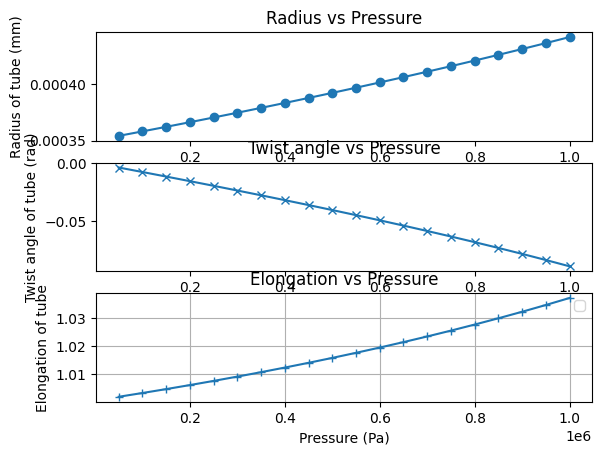

In [ ]:
# Plot differences of tube configuration respect to input pressure
plt.subplot(3,1,1)
plt.plot(P_array, ri_array, marker="o")
plt.title("Radius vs Pressure")
plt.xlabel("Pressure (Pa)")
plt.ylabel("Radius of tube (mm)")
plt.subplot(3,1,2)
plt.plot(P_array, phi_array, marker="x")
plt.title("Twist angle vs Pressure")
plt.xlabel("Pressure (Pa)")
plt.ylabel("Twist angle of tube (rad)")
plt.subplot(3,1,3)
plt.plot(P_array, lbd_array, marker="+")
plt.title("Elongation vs Pressure")
plt.xlabel("Pressure (Pa)")
plt.ylabel("Elongation of tube")
plt.legend()
plt.grid()
plt.show()

